In [22]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# tidy3d imports
import tidy3d as td
import tidy3d.web as web
web.configure(apikey="U6iK3TqIEeIQMdk7ELMzDioV6R4abyHl0M4kEcYh9NmizmJD")

from tidy3d import material_library

sim_path = "220_1550/with_mirror"

Configuration saved successfully.


Running Mode Solver...


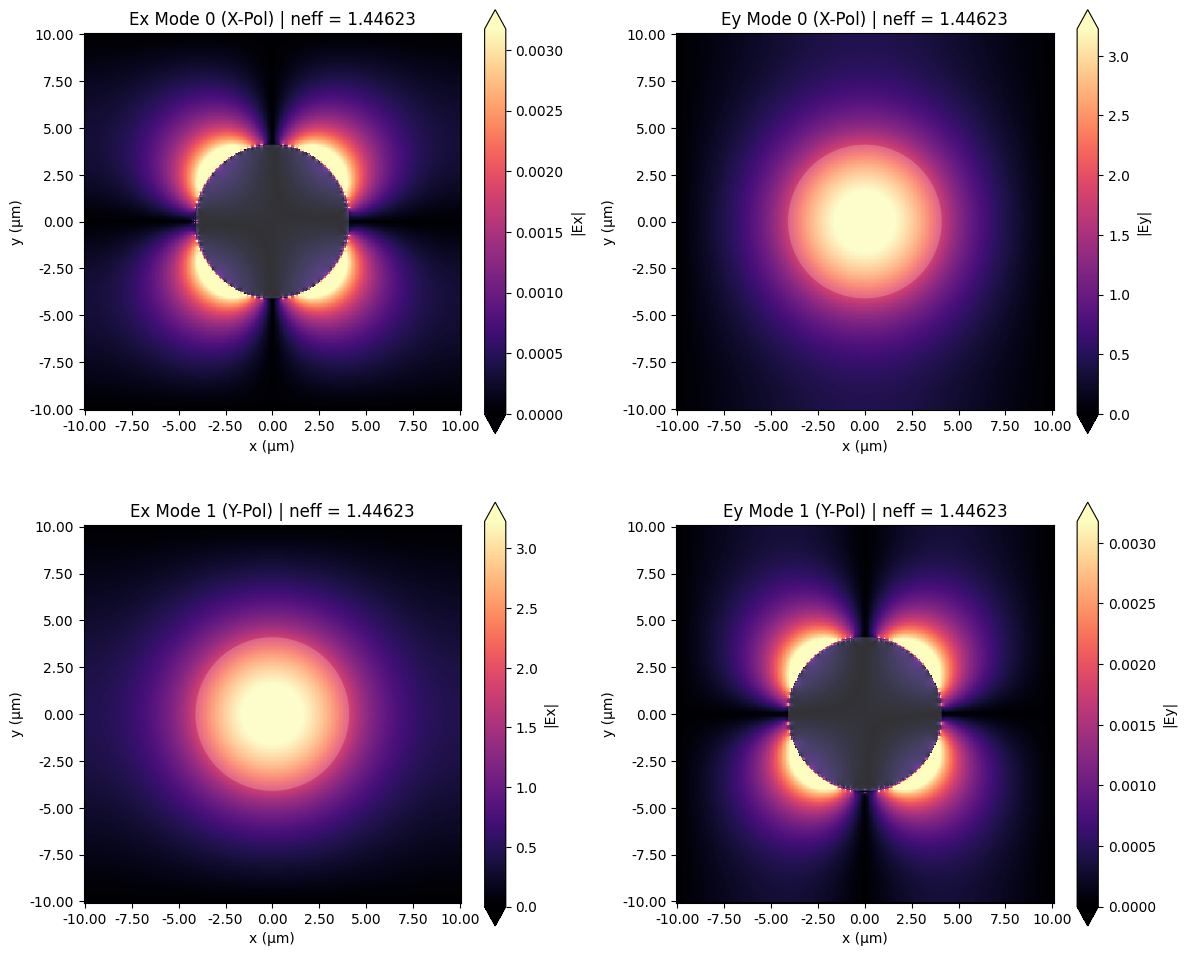


Effective and Group Indices Found:
Mode 0: neff = 1.44623, ngroup = 1.45475
Mode 1: neff = 1.44623, ngroup = 1.45476
Mode 2: neff = 1.44391, ngroup = 1.46277
Mode 3: neff = 1.44390, ngroup = 1.46280


In [23]:
from tidy3d.plugins.mode import ModeSolver

wl0 = 1.55
freq0 = td.C_0 / wl0

fiber_index = 1.449
mat_si = material_library['cSi']['Palik_Lossless']
mat_sio2 = material_library['SiO2']['Palik_Lossless']
mat_fiber_core = td.Medium(permittivity=fiber_index**2)

fiber_core = td.Structure(
    geometry=td.Cylinder(center=(0, 0, 0), radius=4.1, length=td.inf),
    medium=mat_fiber_core,
    name="fiber_core"
)

core_ellipse_stretch = td.Structure(
    geometry=td.Box(
        center=(0, 0, 0), 
        size=(8.2, 0.1, td.inf)
    ),
    medium=mat_fiber_core,
    name="core_ellipse_stretch"
)

simulation=td.Simulation(
    size=(20, 20, 20),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15, wavelength=wl0),
    structures=[fiber_core, core_ellipse_stretch],
    run_time=1e-12, # Required parameter, but unused by mode solver
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=mat_sio2 
)

mode_solver = ModeSolver(
    simulation=simulation,
    plane=td.Box(center=(0, 0, 0), size=(20, 20, 0)),
    mode_spec=td.ModeSpec(
        group_index_step=True,
        num_modes=4,
        target_neff=fiber_index, # Target the core index
    ),
    freqs=[freq0]
)

print("Running Mode Solver...")
mode_data = mode_solver.solve()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot Mode 0 (X-Polarized)
mode_solver.plot_field("Ex", "abs", mode_index=0, ax=axs[0][0])
mode_solver.plot_field("Ey", "abs", mode_index=0, ax=axs[0][1])
n_eff_0 = mode_data.n_eff[0, 0].real
axs[0][0].set_title(f"Ex Mode 0 (X-Pol) | neff = {n_eff_0:.5f}")
axs[0][1].set_title(f"Ey Mode 0 (X-Pol) | neff = {n_eff_0:.5f}")

# Plot Mode 1 (Y-Polarized)
mode_solver.plot_field("Ex", "abs", mode_index=1, ax=axs[1][0])
mode_solver.plot_field("Ey", "abs", mode_index=1, ax=axs[1][1])
n_eff_1 = mode_data.n_eff[0, 1].real
axs[1][0].set_title(f"Ex Mode 1 (Y-Pol) | neff = {n_eff_1:.5f}")
axs[1][1].set_title(f"Ey Mode 1 (Y-Pol) | neff = {n_eff_1:.5f}")

plt.tight_layout()
plt.show()

# Print out the effective indices and the group indices for all modes
print("\nEffective and Group Indices Found:")
for i in range(len(mode_data.n_eff[0])):
    n_eff = mode_data.n_eff[0, i].real
    n_group = mode_data.n_group[0, i].real
    print(f"Mode {i}: neff = {n_eff:.5f}, ngroup = {n_group:.5f}")

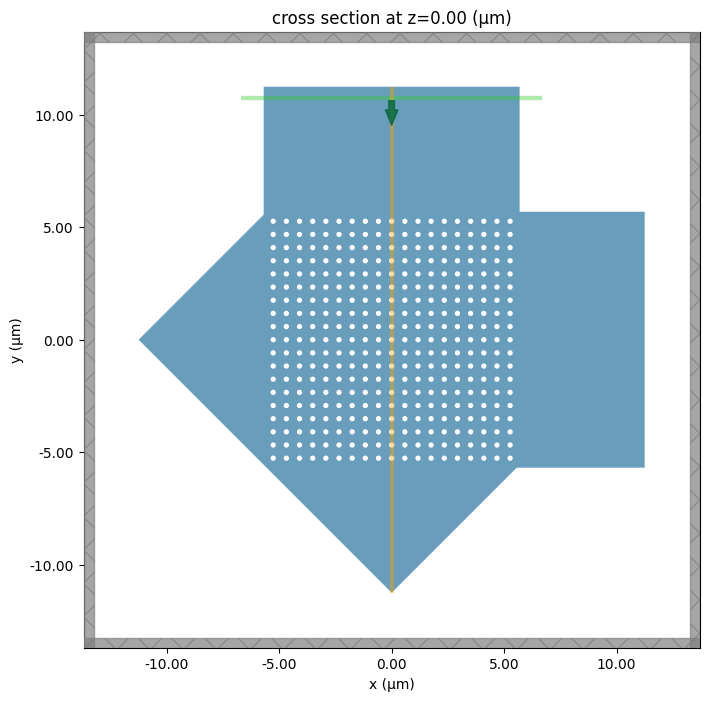

In [24]:
from tidy3d.plugins.smatrix import Port, ComponentModeler

def build_psgc_sim(s_matrix=False, injection_source='waveguide_y', wvl0=1.550, fiber_pol_index=0, period=0.585, duty_cycle=0.400, mirror_shift=5.98):
    # ====================================================================
    # PARAMETERS
    # ====================================================================
    
    target_grating_size = 10.0 
    etch_depth = 0.130

    bandwidth = 0.020 # in um
    wvls = np.linspace(wvl0 - bandwidth/2, wvl0 + bandwidth/2, 51)
    freq0 = td.C_0 / wvl0
    freqs = td.C_0 / wvls
    
    wg_thick = 0.220
    box_thick = 2.0
    sub_thick = 2.0  
    clad_thick = 4.0 

    z_si_top = 0.0
    z_si_bottom = -wg_thick
    z_si_center = (z_si_top + z_si_bottom) / 2.0
    z_etch_center = z_si_top - (etch_depth / 2.0)

    fiber_index = 1.449
    mat_si = material_library['cSi']['Palik_Lossless']
    mat_sio2 = material_library['SiO2']['Palik_Lossless']
    mat_fiber_core = td.Medium(permittivity=fiber_index**2, name="fiber_core")

    # ====================================================================
    # DEVICE GEOMETRY
    # ====================================================================
    
    # Generate Symmetrical Hole Grid (Centered at 0,0)
    num_holes_half = int(np.round((target_grating_size / period) / 2.0)) 
    hole_centers = np.arange(-num_holes_half, num_holes_half + 1) * period
    max_hole_center = np.max(hole_centers)

    # grating_half_width defines the physical boundary of the grating block
    grating_half_width = max_hole_center + (period / 2.0)

    # The optical mirror plane is at the Tip
    mirror_tip_distance = max_hole_center + mirror_shift
    
    # waveguide_half_width defines the 45-degree facet baseline and the waveguide half-width
    waveguide_half_width = mirror_tip_distance - grating_half_width
    
    wg_length = mirror_tip_distance

    geometry = []

    # Substrate & Fiber Core 
    geometry.append(td.Structure(
        geometry=td.Box(center=(0, 0, -box_thick - sub_thick/2), size=(td.inf, td.inf, sub_thick)),
        medium=mat_si, name="substrate"
    ))
    geometry.append(td.Structure(
        geometry=td.Cylinder(center=(0, 0, z_si_top + 1.0 + 5.0), radius=4.1, length=10.0, axis=2),
        medium=mat_fiber_core, name="fiber_core"
    ))
    geometry.append(td.Structure(
        geometry=td.Box(center=(0, 0, z_si_top + 1.0 + 5.0), size=(8.2, 0.1, 10.0)),
        medium=mat_fiber_core, name="fiber_core_midline"
    ))

    # The PSGC Slab (Explicit Dual Corner-Cube Vertices with 45° Facets)
    vertices = [
        (-waveguide_half_width, wg_length),                   # Top left of Y-Waveguide
        (-waveguide_half_width, grating_half_width),          # Start of Left Diamond (Top valley corner)
        (-mirror_tip_distance, 0),                            # Tip of Left Diamond (Retroreflector 1)
        # (-waveguide_half_width, -grating_half_width),         # Bottom of Left Diamond (Left valley corner)
        # (-grating_half_width, -waveguide_half_width),         # Inner connection notch (Bottom valley corner)
        (0, -mirror_tip_distance),                            # Tip of Bottom Diamond (Retroreflector 2)
        (grating_half_width, -waveguide_half_width),          # Right of Bottom Diamond (Right valley corner)
        (wg_length, -waveguide_half_width),                   # Bottom of X-Waveguide
        (wg_length, waveguide_half_width),                    # Top of X-Waveguide
        (waveguide_half_width, waveguide_half_width),         # Inner L-Corner
        (waveguide_half_width, wg_length)                     # Right of Y-Waveguide
    ]
    
    geometry.append(td.Structure(
        geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(z_si_bottom, z_si_top)),
        medium=mat_si, name="psgc_slab"
    ))
    
    # The 2D Hole Array 
    hole_shapes = []
    hole_radius = (duty_cycle * period) / 2.0
    for cx in hole_centers:
        for cy in hole_centers:
            # Generate the hole
            hole_shapes.append(td.Cylinder(
                center=(cx, cy, z_etch_center), 
                radius=hole_radius, 
                length=etch_depth, 
                axis=2
            ))
    geometry.append(td.Structure(
        geometry=td.GeometryGroup(geometries=hole_shapes),
        medium=mat_sio2, name="grating_hole_array"
    ))

    # ====================================================================
    # ROUTING LOGIC (Sources & Monitors)
    # ====================================================================
    sources, monitors = [], []
    monitor_width = waveguide_half_width * 2 + 2.0 
    
    if s_matrix:
        port_wg_x = Port(
            name="port_wg_x",
            center=(wg_length - 0.5, 0, z_si_center),
            size=(0, monitor_width, wg_thick * 4),
            mode_spec=td.ModeSpec(num_modes=1, target_neff=3.0),
            direction="-",
        )
        port_wg_y = Port(
            name="port_wg_y",
            center=(0, wg_length - 0.5, z_si_center),
            size=(monitor_width, 0, wg_thick * 4),
            mode_spec=td.ModeSpec(num_modes=1, target_neff=3.0),
            direction="-",
        )
        port_fiber = Port(
            name="port_fiber",
            center=(0, 0, z_si_top + 3.0),
            size=(14.0, 14.0, 0),
            mode_spec=td.ModeSpec(num_modes=2, target_neff=fiber_index),
            direction="-",
        )
        ports = [port_wg_x, port_wg_y, port_fiber]

    else:
        if injection_source == 'waveguide_x':
            sources.append(td.ModeSource(
                center=(wg_length - 0.5, 0, z_si_center), size=(0, monitor_width, wg_thick * 4),
                source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0/20), direction="-", 
                mode_spec=td.ModeSpec(num_modes=1, target_neff=3.0), mode_index=0, name="wg_x_source"
            ))
            monitors.append(td.ModeMonitor(
                center=(0, 0, z_si_top + 3.0), size=(14.0, 14.0, 0), freqs=freqs,
                mode_spec=td.ModeSpec(num_modes=2, target_neff=fiber_index), name="fiber_port"
            ))
        
        elif injection_source == 'waveguide_y':
            sources.append(td.ModeSource(
                center=(0, wg_length - 0.5, z_si_center), size=(monitor_width, 0, wg_thick * 4),
                source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0/20), direction="-", 
                mode_spec=td.ModeSpec(num_modes=1, target_neff=3.0), mode_index=0, name="wg_y_source"
            ))
            monitors.append(td.ModeMonitor(
                center=(0, 0, z_si_top + 3.0), size=(14.0, 14.0, 0), freqs=freqs,
                mode_spec=td.ModeSpec(num_modes=2, target_neff=fiber_index), name="fiber_port"
            ))

        elif injection_source == 'fiber':
            sources.append(td.ModeSource(
                center=(0, 0, z_si_top + 3.0), size=(14.0, 14.0, 0),
                source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0/20), direction="-", 
                mode_spec=td.ModeSpec(num_modes=2, target_neff=fiber_index), mode_index=fiber_pol_index, name="fiber_source"
            ))
            monitors.append(td.ModeMonitor(
                center=(wg_length - 0.5, 0, z_si_center), size=(0, monitor_width, wg_thick * 4),
                freqs=freqs, mode_spec=td.ModeSpec(num_modes=1, target_neff=3.0), name="out_x"
            ))
            monitors.append(td.ModeMonitor(
                center=(0, wg_length - 0.5, z_si_center), size=(monitor_width, 0, wg_thick * 4),
                freqs=freqs, mode_spec=td.ModeSpec(num_modes=1, target_neff=3.0), name="out_y"
            ))

    monitors.append(td.FieldMonitor(center=(0,0,z_si_center), size=(td.inf, td.inf, 0), freqs=[freq0], name="field_xy"))
    monitors.append(td.FieldMonitor(center=(0,0,z_si_center), size=(0, 2*mirror_tip_distance, td.inf), freqs=[freq0], name="field_yz"))
    monitors.append(td.FieldMonitor(center=(0,0,z_si_top + 3.0), size=(14.0, 14.0, 0), freqs=freqs, name="field_fiber"))
    # monitors.append(td.FieldTimeMonitor(center=(0,0,z_si_center), size=(td.inf, td.inf, 0), name="time_xy"))

    # ====================================================================
    # SIMULATION SETUP   
    # ====================================================================
    z_min = -box_thick - sub_thick
    z_max = z_si_top + clad_thick
    z_center = (z_max + z_min) / 2.0
    z_span = z_max - z_min

    sim = td.Simulation(
        center=(0, 0, z_center),
        size=(wg_length*2 + 4, wg_length*2 + 4, z_span),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=12, wavelength=wvl0),
        structures=geometry, sources=sources, monitors=monitors,
        run_time=2e-12, boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        medium=mat_sio2 
    )

    if s_matrix:
        modeler = ComponentModeler(simulation=sim, ports=ports, freqs=freqs)
        return modeler
    else:
        return sim

# Test the plot rendering
sim_test = build_psgc_sim()
fig, ax = plt.subplots(figsize=(8, 8))
sim_test.plot(z=0, ax=ax)
plt.show()

In [20]:
sim_test.plot_3d()

In [21]:
period = 0.585
duty_cycle = 0.400
mirror_shift = 5.920
sim = build_psgc_sim(injection_source='waveguide_y', period=period, duty_cycle=duty_cycle, mirror_shift=mirror_shift)
task_id = web.upload(sim, task_name=f"source_y_p_{period:.3f}_d_{duty_cycle:.3f}_s_{mirror_shift:.3f}", folder_name=f"2d_gc/{sim_path}/full_test/")
estimate = web.estimate_cost(task_id)

17:16:53 SE Asia Standard Time Created task 'source_y_p_0.585_d_0.400_s_5.920'  
                               with resource_id                                 
                               'fdve-00eeabfe-2c6a-4da5-96b1-01c20ac7f1da' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=377227;https://tidy3d.simulation.cloud/workbench?taskId=fdve-00eeabfe-2c6a-4da5-96b1-01c20ac7f1da\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=50137;https://tidy3d.simulation.cloud/workbench?taskId=fdve-00eeabfe-2c6a-4da5-96b1-01c20ac7f1da\taskId]8;;\
                               ]8;id=377227;https://tidy3d.simulation.cloud/workbench?taskId=fdve-00eeabfe-2c6a-4da5-96b1-01c20ac7f1da\=]8;;\]8;id=221915;https://tidy3d.simulation.cloud/workbench?taskId=fdve-00eeabfe-2c6a-4da5-96b1-01c20ac7f1da\fdve]8;;\]8;id=377227;https://tidy3d.simulation.cloud/workbench?taskId=fdve-00eeabfe-2c6a-4da5-96b1-01c20ac7f1da\-00eeabfe-2c6a-4da5-96b1-01c20ac7f1da']8;;\.

                               Task folder: ]8;id=802884;https://tidy3d.simulation.cloud/folders/folder-f2d95e80-7857-4b04-a21b-95ff96b2994d\'default']8;;\.

Output()

17:17:05 SE Asia Standard Time Estimated FlexCredit cost: 2.113. This assumes   
                               the FDTD solver runs for the full simulation     
                               time; if early shutoff is reached, the billed    
                               cost can be lower. Use 'web.real_cost(task_id)'  
                               to get the billed FlexCredit cost after a        
                               simulation run.

17:17:14 SE Asia Standard Time Estimated FlexCredit cost: 2.113. This assumes   
                               the FDTD solver runs for the full simulation     
                               time; if early shutoff is reached, the billed    
                               cost can be lower. Use 'web.real_cost(task_id)'  
                               to get the billed FlexCredit cost after a        
                               simulation run.

In [ ]:
period = 0.475
duty_cycle = 0.400
mirror_shift = 0.400

sims = {}

sims['waveguide_y'] = build_psgc_sim(injection_source='waveguide_y', period=period, duty_cycle=duty_cycle, mirror_shift=mirror_shift)
sims['waveguide_x'] = build_psgc_sim(injection_source='waveguide_x', period=period, duty_cycle=duty_cycle, mirror_shift=mirror_shift)
sims["fiber_x"] = build_psgc_sim(injection_source='fiber', fiber_pol_index=0, period=period, duty_cycle=duty_cycle, mirror_shift=mirror_shift)
sims["fiber_y"] = build_psgc_sim(injection_source='fiber', fiber_pol_index=1, period=period, duty_cycle=duty_cycle, mirror_shift=mirror_shift)

batch = web.Batch(simulations=sims, folder_name=f"final/p_{period}_d_{duty_cycle}_s_{mirror_shift}/")
batch_results = batch.run(path_dir=f"data/final/p_{period}_d_{duty_cycle}_s_{mirror_shift}/")

In [ ]:
periods = [0.425]
duties = [0.400]
shifts = np.linspace(5.780, 5.820, 5)

sims = {}
for p in periods:
    for d in duties:
        for s in shifts:
            name = f"p_{p:.3f}_d_{d:.3f}_s_{s:.3f}"
            sims[name] = build_psgc_sim(period=p, duty_cycle=d, mirror_shift=s)

print(f"Total simulations to run: {len(sims)}")
batch = web.Batch(simulations=sims, folder_name=f"2d_gc/{sim_path}/shifts_sweep/", verbose=True)
batch.estimate_cost()
# batch_results = batch.run(path_dir=f"data/{sim_path}/shifts_sweep/")

Total simulations to run: 5


15:16:44 SE Asia Standard Time Maximum FlexCredit cost: 20.178 for the whole    
                               batch.

20.178443863603228

In [36]:
batch_results = batch.run(path_dir=f"data/{sim_path}/shifts_sweep/")    

Output()

15:17:58 SE Asia Standard Time Started working on Batch containing 5 tasks.

15:18:57 SE Asia Standard Time Maximum FlexCredit cost: 20.178 for the whole    
                               batch.

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after completion.

Output()

15:22:58 SE Asia Standard Time Batch complete.

In [ ]:
# analyze sweep results


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td

# Preferred propagation direction at the mode monitor.
# For your fiber_port monitor (normal along z), "+" is usually the upward direction.
preferred_direction = "+"

# dB floor to avoid log(0) and keep plots readable.
power_floor_db = -40.0
power_floor_linear = 10 ** (power_floor_db / 10.0)

def pick_name(data_array, preferred_names):
    for n in preferred_names:
        if n in data_array.coords or n in data_array.dims:
            return n
    return None

def safe_select_mode(data_array, mode_dim, mode_idx):
    # Try label-based select first, then fallback to positional index.
    try:
        return data_array.sel({mode_dim: mode_idx})
    except Exception:
        return data_array.isel({mode_dim: mode_idx})

n_sims = len(batch_results)
ncols = 2
nrows = int(np.ceil(n_sims / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.2 * nrows), squeeze=False)
axes = axes.ravel()

for ax, (sim_name, sim_data) in zip(axes, batch_results.items()):
    mode_data = sim_data["fiber_port"]
    amps = mode_data.amps  # complex modal amplitudes

    freq_dim = pick_name(amps, ["f", "freq", "frequency"])
    mode_dim = pick_name(amps, ["mode_index", "mode", "m"])
    dir_dim = pick_name(amps, ["direction", "dir"])

    if freq_dim is None:
        raise ValueError(f"Could not find frequency coordinate for {sim_name}. Dims: {amps.dims}")
    if mode_dim is None:
        raise ValueError(f"Could not find mode coordinate for {sim_name}. Dims: {amps.dims}")

    # Select one propagation direction if direction axis exists.
    if dir_dim is not None:
        dirs = [str(v) for v in amps[dir_dim].values]
        if preferred_direction in dirs:
            amps_use = amps.sel({dir_dim: preferred_direction})
        elif "+" in dirs:
            amps_use = amps.sel({dir_dim: "+"})
        elif "-" in dirs:
            amps_use = amps.sel({dir_dim: "-"})
        else:
            amps_use = amps.isel({dir_dim: 0})
    else:
        amps_use = amps

    freqs = np.asarray(amps_use[freq_dim].values, dtype=float)
    wavelengths = td.C_0 / freqs  # um (Tidy3D default units)

    # Plot both fiber modes in dB: 10*log10(|amp|^2).
    for mi, color in zip([0, 1], ["tab:blue", "tab:orange"]):
        a_mode = safe_select_mode(amps_use, mode_dim, mi)
        intensity_linear = np.abs(np.asarray(a_mode.values)) ** 2
        intensity_db = 10.0 * np.log10(np.maximum(intensity_linear, power_floor_linear))

        # Sort by wavelength so x-axis increases left->right
        order = np.argsort(wavelengths)
        ax.plot(wavelengths[order], intensity_db[order], lw=2, color=color, label=f"Mode {mi}")

    ax.set_title(sim_name)
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Intensity (dB), 10log10(|amp|^2)")
    ax.set_ylim(power_floor_db, None)
    ax.grid(alpha=0.3)
    ax.legend()

# Hide any empty subplot slots
for k in range(n_sims, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
modeler = build_psgc_sim(s_matrix=True, injection_source='fiber', period=0.585, duty_cycle=0.400, mirror_shift=0.420)
# modeler.plot_sim(x=0)
modeler_data = web.run(modeler, verbose=True, path="2d_gc/final/p_585_d_400_s_420/s_matrix.hdf5", folder_name="2d_gc/final/p_585_d_400_s_420/")

In [ ]:
modeler_data = web.load(task_id="sid-9786a21d-45b0-451c-a76f-33246250345c")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

s_matrix = modeler_data.smatrix()
s21 = s_matrix.sel(port_in='port_fiber', port_out='port_wg_y', mode_index_in=0, mode_index_out=0)

c = 299792458  # Speed of light in m/s
freqs_hz = s21.coords['f'].values
wavelengths_nm = (c / freqs_hz) * 1e9

transmission_linear = np.abs(s21.values)**2
transmission_dB = 10 * np.log10(transmission_linear)

plt.figure(figsize=(8, 5))
plt.plot(wavelengths_nm, transmission_dB, color='blue', linewidth=2)

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Transmission (dB)', fontsize=12)
plt.title('Device Transmission', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Display
plt.show()

In [ ]:
import numpy as np

# 1. Define the Lumerical Port Mapping
# Mapping: (Tidy3D_Port, Tidy3D_Mode, Lum_Port_Name, Lum_Out_Mode_Label, Lum_Mode_ID)
logical_ports = [
    ('port_wg_x', 0, 'WG_X', 'TE', 1),   # Waveguide X (TE)
    ('port_wg_y', 0, 'WG_Y', 'TE', 1),   # Waveguide Y (TE)
    ('port_fiber', 0, 'Fiber', 'TE', 1), # Fiber X-Pol (TE)
    ('port_fiber', 1, 'Fiber', 'TM', 2)  # Fiber Y-Pol (TM)
]

# --- Define physical port layout and custom names for INTERCONNECT ---
port_positions = [
    ('WG_X', 'RIGHT'),  
    ('WG_Y', 'RIGHT'),  
    ('Fiber', 'LEFT')   
]

# 2. Extract frequencies
freqs_hz = s_matrix.coords['f'].values
num_freqs = len(freqs_hz)

# 3. Open the .dat file and populate the matrix
output_filepath = 'final/psgc_lumerical.dat'

with open(output_filepath, 'w') as f:
    
    # Write the Port Position Definitions at the very top
    for port_name, position in port_positions:
        f.write(f'["{port_name}", "{position}"]\n')
        
    # Write the S-Parameter Data Blocks
    for out_tidy_port, out_tidy_mode, out_lum_port, out_lum_mode, out_lum_id in logical_ports:
        for in_tidy_port, in_tidy_mode, in_lum_port, in_lum_mode, in_lum_id in logical_ports:
            
            # Write Lumerical Header using the custom names
            f.write(f'("{out_lum_port}", "{out_lum_mode}", {out_lum_id}, "{in_lum_port}", {in_lum_id}, "transmission")\n')
            f.write(f'({num_freqs}, 3)\n')
            
            # Extract specific S-parameter array from Tidy3D
            s_data = s_matrix.sel(
                port_out=out_tidy_port, mode_index_out=out_tidy_mode,
                port_in=in_tidy_port, mode_index_in=in_tidy_mode
            ).values
            
            # Convert complex to magnitude (linear) and phase (radians)
            magnitude = np.abs(s_data)
            phase = np.angle(s_data)
            
            # Write data rows
            for i in range(num_freqs):
                f.write(f"{freqs_hz[i]:.6e} {magnitude[i]:.6f} {phase[i]:.6f}\n")

print(f"Export to {output_filepath} successful!")

In [ ]:
import numpy as np
import skrf as rf

# 1. Define the Touchstone Port Mapping
# We map your Tidy3D (port_name, mode_index) to standard Touchstone ports (1, 2, 3, 4).
# Keep this mapping handy! You will need it when wiring the component in PhotonForge/Lumerical.
logical_ports = [
    ('port_wg_x', 0),  # Touchstone Port 1
    ('port_wg_y', 0),  # Touchstone Port 2
    ('port_fiber', 0), # Touchstone Port 3 (e.g., X-Pol)
    ('port_fiber', 1)  # Touchstone Port 4 (e.g., Y-Pol)
]
num_ports = len(logical_ports)

# 2. Extract frequencies and format for scikit-rf
freqs_hz = s_matrix.coords['f'].values
skrf_freq = rf.Frequency.from_f(freqs_hz, unit='hz')

# 3. Initialize the empty NxN S-matrix array 
# scikit-rf requires shape: [number_of_frequencies, output_ports, input_ports]
s_array = np.zeros((len(freqs_hz), num_ports, num_ports), dtype=complex)

# 4. Populate the matrix
for i, (port_out, mode_out) in enumerate(logical_ports):
    for j, (port_in, mode_in) in enumerate(logical_ports):
        
        # S_ij = output i, input j
        s_data = s_matrix.sel(
            port_out=port_out, mode_index_out=mode_out,
            port_in=port_in, mode_index_in=mode_in
        ).values
        
        s_array[:, i, j] = s_data

# 5. Build the Network object and export
psgc_network = rf.Network(frequency=skrf_freq, s=s_array, name='psgc_component')

# Writes to a 4-port touchstone file (.s4p)
psgc_network.write_touchstone('2d_gc/final/psgc_4port.s4p')

print("Export successful! Port Mapping:")
for i, (p_name, m_idx) in enumerate(logical_ports):
    print(f"Port {i+1}: {p_name} (Mode {m_idx})")

In [48]:
# STRUCTURE GDS EXPORT
import gdstk

filename = "psgc_220_1550.gds"

freq0 = td.C_0 / 1.55
psgc_sim = build_psgc_sim(period=0.585, duty_cycle=0.400, mirror_shift=5.98)

psgc_slab_struct = next(s for s in psgc_sim.structures if s.name == "psgc_slab")
hole_array_struct = next(
    s for s in psgc_sim.structures if s.name == "grating_hole_array"
)

vertices = psgc_slab_struct.geometry.vertices
hole_cylinders = hole_array_struct.geometry.geometries
hole_radius = hole_cylinders[0].radius
hole_centers = [(cyl.center[0], cyl.center[1]) for cyl in hole_cylinders]

# ====================================================================
# Layer Map for SiEPIC EBeam PDK
# ====================================================================
LAYER_SI = (1, 0)  # Full 220nm Silicon
LAYER_ETCH = (2, 0)  # 130nm Shallow Etch / Slab
LAYER_DEVREC = (68, 0)  # Device Recognition (DRC & Netlist)
LAYER_FBRTGT = (81, 0)  # Fiber Target Alignment Marker

# Build GDSTK Cell
lib = gdstk.Library(name="SiEPIC_PSGC")
cell = lib.new_cell("PSGC")

# Layer (1,0) -> Full 220nm Silicon Base Outline
psgc_base = gdstk.Polygon(vertices, layer=LAYER_SI[0], datatype=LAYER_SI[1])
cell.add(psgc_base)

# Layer (2,0) -> 130nm Shallow Etch Holes
for cx, cy in hole_centers:
    hole_circle = gdstk.ellipse(
        (cx, cy),
        radius=hole_radius,
        tolerance=0.001,
        layer=LAYER_ETCH[0],
        datatype=LAYER_ETCH[1],
    )
    cell.add(hole_circle)

# Layer (68,0) -> DevRec Boundary Box
# Wrap the bounding box of the entire device plus a small margin (e.g., 0.5 um)
bbox = cell.bounding_box()
margin = 0.5
devrec_box = gdstk.rectangle(
    (bbox[0][0] - margin, bbox[0][1] - margin),
    (bbox[1][0] + margin, bbox[1][1] + margin),
    layer=LAYER_DEVREC[0],
    datatype=LAYER_DEVREC[1],
)
cell.add(devrec_box)

# Layer (81,0) -> FbrTgt Fiber Target Circle
# Places a fiber core target indicator (e.g. 9.0 um diameter or MFD circle) at (0,0)
fiber_target_radius = 4.5  # 9.0 um diameter for SiEPIC Ebeam
fbr_tgt = gdstk.ellipse(
    (0, 0),  # Positioned at origin (0,0) where the fiber aligns
    radius=fiber_target_radius,
    tolerance=0.001,
    layer=LAYER_FBRTGT[0],
    datatype=LAYER_FBRTGT[1],
)
cell.add(fbr_tgt)

# Save GDS File
lib.write_gds(filename)

In [ ]:
psgc_sim.structures

(Structure(geometry=Box(center=(0.0, 0.0, -3.0), size=(inf, inf, 2.0)), name='substrate', background_permittivity=None, background_medium=None, priority=None,medium=cSi_PalikLowLoss),
 Structure(geometry=Cylinder(axis=2, sidewall_angle=0.0, reference_plane='middle', radius=4.1, center=(0.0, 0.0, 6.0), length=10.0), name='fiber_core', background_permittivity=None, background_medium=None, priority=None,medium=fiber_core),
 Structure(geometry=Box(center=(0.0, 0.0, 6.0), size=(8.2, 0.1, 10.0)), name='fiber_core_midline', background_permittivity=None, background_medium=None, priority=None,medium=fiber_core),
 Structure(geometry=PolySlab(axis=2, sidewall_angle=0.0, reference_plane='middle', slab_bounds=(-0.22, 0.0), dilation=0.0, vertices=array([[ -5.6875, 11.245 ], [ -5.6875, 5.5575], [-11.245 , 0. ], [ 0. , -11.245 ], [ 5.5575, -5.6875], [ 11.245 , -5.6875], [ 11.245 , 5.6875], [ 5.6875, 5.6875], [ 5.6875, 11.245 ]]), bulges=None), name='psgc_slab', background_permittivity=None, background